In [ ]:
# GWTC-5.0 Catalog Tutorial: Population Overview and Single-Event Inference

## Overview

In this tutorial we work with two complementary datasets from the LIGO–Virgo–KAGRA
Gravitational-Wave Transient Catalog 5.0 (**GWTC-5.0**):

1. **The PESummary Table** (`IGWN-GWTC5p0-PESummaryTable.hdf5`): a compact table of
   median parameter values and 90% credible intervals for all ~104 events, computed with
   several waveform approximants.

2. **GW250114 Posterior Samples** (`GW250114_PEsummary.hdf5`): the full posterior
   distributions from the Bayesian parameter-estimation (PE) analysis of a single event,
   giving access to the complete multi-dimensional probability distribution over source
   parameters.

### What we will do

| Part | Content |
|------|---------|
| **Part 1 — Catalog overview** | Load and explore the summary table; select a consistent waveform model; visualise population trends with error bars; examine the SNR–precision relationship |
| **Part 2 — Single-event inference** | Load full posterior samples for GW250114; plot 1-D marginal distributions; make corner plots showing parameter correlations; compare priors and posteriors; compare across waveform models |

> **Prerequisite packages**: `gwpy`, `pesummary`, `numpy`, `matplotlib`, `corner`


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import corner

from gwpy.table import EventTable
from pesummary.io import read

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})
print("All packages loaded successfully.")


result_label,gw_name,result_file_name,result_samples_key,superevent_id,total_mass_source_median,total_mass_source_lower,total_mass_source_upper,chirp_mass_source_median,chirp_mass_source_lower,chirp_mass_source_upper,mass_1_source_median,mass_1_source_lower,mass_1_source_upper,mass_2_source_median,mass_2_source_lower,mass_2_source_upper,final_mass_source_median,final_mass_source_median.mask,final_mass_source_lower,final_mass_source_lower.mask,final_mass_source_upper,final_mass_source_upper.mask,chi_eff_median,chi_eff_lower,chi_eff_upper,final_spin_median,final_spin_median.mask,final_spin_lower,final_spin_lower.mask,final_spin_upper,final_spin_upper.mask,luminosity_distance_median,luminosity_distance_lower,luminosity_distance_upper,redshift_median,redshift_lower,redshift_upper,network_matched_filter_snr_median,network_matched_filter_snr_median.mask,network_matched_filter_snr_lower,network_matched_filter_snr_lower.mask,network_matched_filter_snr_upper,network_matched_filter_snr_upper.mask,skymap_result_file_name
bytes44,bytes15,bytes69,bytes28,bytes9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,bytes95
GW240413_022019-C00:IMRPhenomXPHM-SpinTaylor,GW240413_022019,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-combined_PEDataRelease.hdf5,C00:IMRPhenomXPHM-SpinTaylor,S240413p,13.563028963733172,0.5198591799304833,1.4062068184593226,5.739934134201354,0.10652773291751583,0.2273740795604029,7.9209406576251284,1.1956136975853955,2.8033875334613034,5.567223676543753,1.346452513756172,0.9562177379417678,12.924838149827206,False,0.5190913053935855,False,1.4901190222364349,False,0.06557707015719375,0.04339495728002539,0.1366299788725294,0.6963413954451871,False,0.03935984195376918,False,0.03242950597392902,False,571.9658536474074,217.29426707202555,108.66806341633878,0.11885163450829132,0.04300922654539152,0.020725634568693516,17.33049415997603,False,0.24391523482472977,False,0.15666656827532677,False,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-IMRPhenomXPHM_SpinTaylor_Skymap_PEDataRelease.fits.gz
GW240413_022019-C00:IMRPhenomXPNR,GW240413_022019,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-combined_PEDataRelease.hdf5,C00:IMRPhenomXPNR,S240413p,13.54553480038295,0.5129032202673649,1.4156831338910294,5.740042905733038,0.10880620965024335,0.22678775603676282,7.892896880267391,1.1767718284981168,2.801740661957745,5.594451701253033,1.3616091619045818,0.9355857898979716,12.909819607985119,False,0.513730736188128,False,1.4863465389997668,False,0.059598949055374634,0.04091301775282469,0.13702986181008975,0.6953325822925072,False,0.03886219898879839,False,0.02919721518308782,False,567.7166427671395,216.07609123585485,111.03436488463399,0.11803127798056436,0.042805150109122655,0.021190904292105253,17.326228028849158,False,0.25416862307479704,False,0.16243501750451728,False,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-IMRPhenomXPNR_Skymap_PEDataRelease.fits.gz
GW240413_022019-C00:SEOBNRv5PHM,GW240413_022019,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-combined_PEDataRelease.hdf5,C00:SEOBNRv5PHM,S240413p,13.49546836090014,0.4655221872932689,0.9701353238320127,5.745391545327252,0.11567016615268244,0.22544021344073872,7.725382044392585,1.0061665889168392,2.1383533515535937,5.721808763674368,1.1829704880928027,0.8280107223486235,nan,True,nan,True,nan,True,0.0579072007738276,0.03746965673922371,0.10286228679233297,nan,True,nan,True,nan,True,562.243025,214.16813649999995,120.48411800000008,0.1169727959117337,0.042472906639013,0.02299902244234761,nan,True,nan,True,nan,True,IGWN-GWTC5p0-59d160a18_25-GW240413_022019-SEOBNRv5PHM_Skymap_PEDataRelease.fits.gz
GW240414_054515-C00:IMRPhenomXPHM-SpinTaylor,GW240414_054515,IGWN-GWTC5p0-59d160a18_25-GW240414_054515-combined_PEDataRelease.hdf5,C00:IMRPhenomXPHM-SpinTaylor,S240414s,65.0140983247910

---
## Part 1: GWTC-5.0 Catalog — Population Overview

### Section 1 · Loading the Summary Table

The PESummary Table is a compact HDF5 file produced by the GWTC-5.0 analysis pipeline.
Each **row** corresponds to one parameter-estimation run: because several waveform
approximants are analysed for each event, the table has more rows than unique events.

Each **column** reports a marginalised 1-D parameter summary:

| Column pattern | Meaning |
|----------------|---------|
| `X_median` | Posterior median |
| `X_lower` | Median − 5th‑percentile (lower 90% CI **offset**) |
| `X_upper` | 95th‑percentile − median (upper 90% CI **offset**) |

So the asymmetric 90% credible interval is:
$$\left[\,X_{\rm median} - X_{\rm lower},\quad X_{\rm median} + X_{\rm upper}\,\right]$$

Available physics quantities include source-frame masses, effective spin $\chi_{\rm eff}$,
luminosity distance, redshift, and network matched-filter SNR.


In [ ]:
summary_path = "./IGWN-GWTC5p0-59d160a18_25-PESummaryTable.hdf5"
summary_table = EventTable.read(summary_path)

unique_events = sorted(set(str(name) for name in summary_table['gw_name']))
print(f"File:           {summary_path}")
print(f"Total rows:     {len(summary_table)}  (multiple models per event)")
print(f"Unique events:  {len(unique_events)}")
print(f"Columns:        {len(summary_table.colnames)}")
print()
print("First 5 event names:", unique_events[:5])
print("Last  5 event names:", unique_events[-5:])


In [ ]:
model_counts = Counter(str(k) for k in summary_table['result_samples_key'])

print("Available waveform approximants and how many events each covers:")
print("─" * 60)
for model, count in sorted(model_counts.items(), key=lambda x: -x[1]):
    bar = "█" * (count // 3)
    print(f"  {model:<44s}  {count:>3d}  {bar}")
print("─" * 60)
print(f"  Total rows: {len(summary_table)}")


['result_label',
 'gw_name',
 'result_file_name',
 'result_samples_key',
 'superevent_id',
 'total_mass_source_median',
 'total_mass_source_lower',
 'total_mass_source_upper',
 'chirp_mass_source_median',
 'chirp_mass_source_lower',
 'chirp_mass_source_upper',
 'mass_1_source_median',
 'mass_1_source_lower',
 'mass_1_source_upper',
 'mass_2_source_median',
 'mass_2_source_lower',
 'mass_2_source_upper',
 'final_mass_source_median',
 'final_mass_source_median.mask',
 'final_mass_source_lower',
 'final_mass_source_lower.mask',
 'final_mass_source_upper',
 'final_mass_source_upper.mask',
 'chi_eff_median',
 'chi_eff_lower',
 'chi_eff_upper',
 'final_spin_median',
 'final_spin_median.mask',
 'final_spin_lower',
 'final_spin_lower.mask',
 'final_spin_upper',
 'final_spin_upper.mask',
 'luminosity_distance_median',
 'luminosity_distance_lower',
 'luminosity_distance_upper',
 'redshift_median',
 'redshift_lower',
 'redshift_upper',
 'network_matched_filter_snr_median',
 'network_matched_filte

In [ ]:
colnames = summary_table.colnames
mass_cols = [c for c in colnames if 'mass' in c and 'mask' not in c]
spin_cols = [c for c in colnames if ('chi' in c or 'spin' in c) and 'mask' not in c]
dist_cols = [c for c in colnames if 'distance' in c or 'redshift' in c]
snr_cols  = [c for c in colnames if 'snr' in c and 'mask' not in c]
id_cols   = ['result_label', 'gw_name', 'result_samples_key', 'superevent_id']

print("Identity columns:")
for c in id_cols:
    print(f"    {c}")

print("\nMass parameters  (each stored as median / lower_offset / upper_offset):")
for c in mass_cols:
    print(f"    {c}")

print("\nSpin parameters:")
for c in spin_cols:
    print(f"    {c}")

print("\nDistance / redshift:")
for c in dist_cols:
    print(f"    {c}")

print("\nNetwork matched-filter SNR:")
for c in snr_cols:
    print(f"    {c}")


gw_name,total_mass_source_median,luminosity_distance_median,redshift_median,chi_eff_median
bytes15,float64,float64,float64,float64
GW240413_022019,13.563028963733172,571.9658536474074,0.11885163450829132,0.06557707015719375
GW240414_054515,65.01409832479102,1525.4837741479232,0.28759479742608907,0.029907255213019377
GW240420_175625,58.60782152740144,2031.0870452586028,0.368156798879015,0.00447105612705628
GW240426_031451,87.95098164208639,4000.28803911404,0.6493172403874246,-0.047000177712996756
GW240428_225440,34.5789784365194,840.647605529873,0.16927163113070617,0.03211571325585246
GW240501_033534,66.15260290376446,4695.761323416528,0.7405336519340533,0.037024808319043194
GW240505_133552,54.04812169179339,4693.063597022441,0.7401857456307938,-0.1309980413801971
GW240507_041632,39.93754387265439,1454.4575818529527,0.27587343972339334,0.012743309214688942
GW240511_031507,72.62719343871856,1990.6183108406444,0.36187666432423904,0.04860659297372878


In [ ]:
---
### Section 2 · Inspecting an Individual Row

Let's look at a specific event — **GW250114_082203** — to understand the data layout
before building population plots.

> **Exercise:** What can you infer from the upper/lower offsets compared to the median?
> Are the posteriors symmetric? Which parameters look the most/least constrained?


In [ ]:
# Find GW250114 in the full table (with all models)
gw_names_str = [str(name) for name in summary_table['gw_name']]
idx250114 = next((i for i, n in enumerate(gw_names_str) if "GW250114" in n), None)
row = summary_table[idx250114]

print(f"Event: {row['gw_name']}  |  Model: {row['result_samples_key']}")
print()
print("Parameter                   Median       Lower offset    Upper offset    90% CI width")
print("─" * 90)
for name, med_col, lo_col, hi_col, unit in [
    ("mass_1_source [Msun]",  "mass_1_source_median",       "mass_1_source_lower",        "mass_1_source_upper",        ""),
    ("mass_2_source [Msun]",  "mass_2_source_median",       "mass_2_source_lower",        "mass_2_source_upper",        ""),
    ("chirp_mass [Msun]",     "chirp_mass_source_median",   "chirp_mass_source_lower",    "chirp_mass_source_upper",    ""),
    ("chi_eff",               "chi_eff_median",              "chi_eff_lower",              "chi_eff_upper",              ""),
    ("distance [Mpc]",        "luminosity_distance_median", "luminosity_distance_lower",  "luminosity_distance_upper",  ""),
    ("redshift",              "redshift_median",             "redshift_lower",             "redshift_upper",             ""),
]:
    med = row[med_col]
    lo  = row[lo_col]
    hi  = row[hi_col]
    width = lo + hi
    sym   = "≈" if abs(hi - lo) / (width + 1e-12) < 0.1 else "asym"
    print(f"  {name:<28s}  {med:>10.3f}   -{lo:>8.3f}  +{hi:>8.3f}   {width:>8.3f}  {sym}")


---
### Section 3 · Selecting One Consistent Waveform Model

Different waveform approximants make different modelling assumptions, so mixing them
when building population plots would introduce systematic biases. We choose one model
for the entire catalog comparison:

| Approximant | Description |
|-------------|-------------|
| **`IMRPhenomXPHM-SpinTaylor`** | Precessing, higher-mode phenomenological model with spin-Taylor phase. Covers the most events (103/104). |
| `IMRPhenomXPNR` | Next-generation precessing phenomenological model with NR-tuned phase |
| `SEOBNRv5PHM` | Spinning EOB model with precession and higher modes |
| `NRSur7dq4` | Direct numerical-relativity surrogate (restricted parameter range) |

We use **`C00:IMRPhenomXPHM-SpinTaylor`** as our reference model throughout Part 1.


In [ ]:
MODEL_KEY = "C00:IMRPhenomXPHM-SpinTaylor"
imr_table = summary_table.filter(f"result_samples_key='{MODEL_KEY}'")

print(f"Model:  {MODEL_KEY}")
print(f"Events: {len(imr_table)}")
print()

analysis_cols = [
    "gw_name",
    "total_mass_source_median",
    "mass_1_source_median",
    "mass_2_source_median",
    "chirp_mass_source_median",
    "chi_eff_median",
    "luminosity_distance_median",
    "redshift_median",
    "network_matched_filter_snr_median",
]
imr_table[analysis_cols][:8]


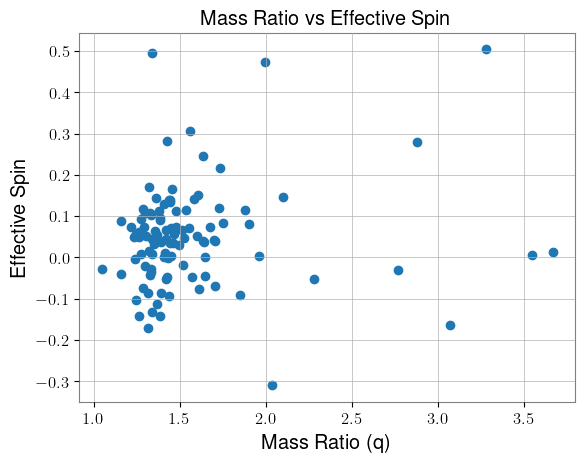

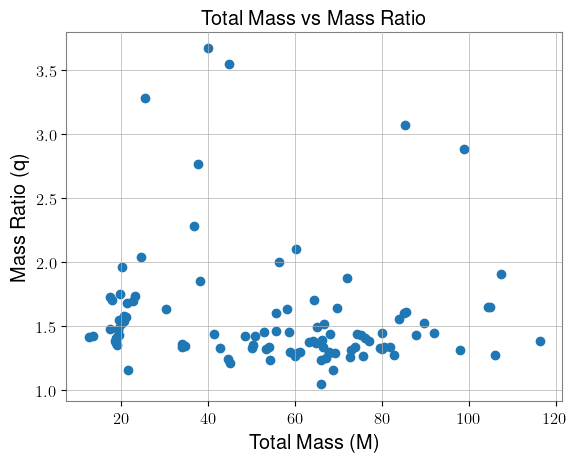

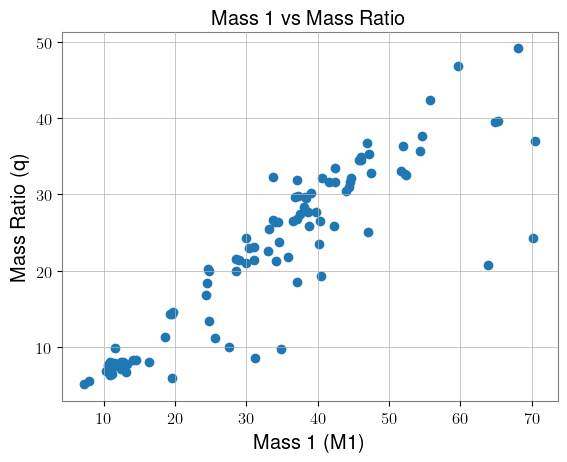

In [ ]:
---
### Section 4 · Derived Quantities

Two combinations of component masses appear frequently in GW science:

**Mass ratio** $q \equiv m_1 / m_2 \geq 1$ (by convention $m_1 \geq m_2$):
$$q = \frac{m_1}{m_2}$$

**Symmetric mass ratio** $\eta$:
$$\eta = \frac{m_1\,m_2}{(m_1+m_2)^2}$$

For equal masses ($q=1$): $\eta = 0.25$ (maximum); for very unequal masses: $\eta \to 0$.

$\eta$ appears directly in the leading-order GW phase and is one of the best-measured
parameters from the chirp waveform (along with the chirp mass $\mathcal{M}$).


m1 = imr_table["mass_1_source_median"]
m2 = imr_table["mass_2_source_median"]

imr_table["mass_ratio_median"]           = m1 / m2
imr_table["symmetric_mass_ratio_median"] = (m1 * m2) / (m1 + m2) ** 2

# ── Sanity check: print GW250114 values ─────────────────────────────────────
gw_names = [str(name) for name in imr_table["gw_name"]]
idx = next((i for i, n in enumerate(gw_names) if "GW250114" in n), None)
if idx is not None:
    r = imr_table[idx]
    print("GW250114_082203 (IMRPhenomXPHM-SpinTaylor):")
    print(f"  m1       = {r['mass_1_source_median']:.2f}  (+{r['mass_1_source_upper']:.2f} / -{r['mass_1_source_lower']:.2f}) Msun")
    print(f"  m2       = {r['mass_2_source_median']:.2f}  (+{r['mass_2_source_upper']:.2f} / -{r['mass_2_source_lower']:.2f}) Msun")
    print(f"  q        = {r['mass_ratio_median']:.3f}")
    print(f"  eta      = {r['symmetric_mass_ratio_median']:.4f}")
    print(f"  chi_eff  = {r['chi_eff_median']:.3f}  (+{r['chi_eff_upper']:.3f} / -{r['chi_eff_lower']:.3f})")
    print(f"  d_L      = {r['luminosity_distance_median']:.0f}  (+{r['luminosity_distance_upper']:.0f} / -{r['luminosity_distance_lower']:.0f}) Mpc")
    print(f"  SNR      = {r['network_matched_filter_snr_median']:.1f}")

imr_table["gw_name", "mass_ratio_median", "symmetric_mass_ratio_median"][:5]


---
### Section 5 · Population Plots with Asymmetric Error Bars

Now we visualise the population using the median values as markers and the 90%
credible-interval offsets as error bars. The error bars are **asymmetric**: the lower
error extends `X_lower` below the median and the upper error extends `X_upper` above it.

These plots reveal:
- The **mass distribution** of the binary population detected in O4
- The **distance-redshift** relation (a useful sanity check: we expect the Hubble flow)
- The **spin signature** in $\chi_{\rm eff}$ across the population


## 1) Catalog Challenge: Ask & Answer Scientific Questions

Try to answer these with code before looking at the helper outputs:

1. Which event has the largest source-frame total mass?
2. Which event is the farthest (largest luminosity distance / redshift)?
3. Is there a visible trend between mass ratio and effective spin?
4. Which systems look most asymmetric in component masses?

Then compare your answers with the ranking tables below.

In [12]:
# Build a compact table with columns useful for ranking.
catalog_view = imr_table[
    "gw_name",
    "total_mass_source_median",
    "mass_1_source_median",
    "mass_2_source_median",
    "mass_ratio_median",
    "chi_eff_median",
    "luminosity_distance_median",
    "redshift_median",
]

catalog_view[:5]

gw_name,total_mass_source_median,mass_1_source_median,mass_2_source_median,mass_ratio_median,chi_eff_median,luminosity_distance_median,redshift_median
bytes15,float64,float64,float64,float64,float64,float64,float64
GW240413_022019,13.563028963733172,7.9209406576251284,5.567223676543753,1.4227811055981519,0.06557707015719375,571.9658536474074,0.11885163450829132
GW240414_054515,65.01409832479102,38.80848366624208,25.92467755516009,1.4969707370002594,0.029907255213019377,1525.4837741479232,0.28759479742608907
GW240420_175625,58.60782152740144,34.58109851428375,23.83141300823687,1.4510720997672888,0.00447105612705628,2031.0870452586028,0.368156798879015
GW240426_031451,87.95098164208639,51.95336036418079,36.37010904484371,1.4284631453846675,-0.047000177712996756,4000.28803911404,0.6493172403874246
GW240428_225440,34.5789784365194,19.769659232837174,14.65823909048158,1.348706288033924,0.03211571325585246,840.647605529873,0.16927163113070617


In [13]:
# Ranking helpers for quick scientific questions.
most_massive = catalog_view[np.argsort(catalog_view["total_mass_source_median"])[::-1]][:5]
most_distant = catalog_view[np.argsort(catalog_view["luminosity_distance_median"])[::-1]][:5]
largest_redshift = catalog_view[np.argsort(catalog_view["redshift_median"])[::-1]][:5]

print("Top 5 by source-frame total mass")
display(most_massive["gw_name", "total_mass_source_median", "mass_ratio_median", "chi_eff_median"])

print("Top 5 by luminosity distance")
display(most_distant["gw_name", "luminosity_distance_median", "redshift_median"])

print("Top 5 by redshift")
display(largest_redshift["gw_name", "redshift_median", "luminosity_distance_median"])

Top 5 by source-frame total mass


gw_name,total_mass_source_median,mass_ratio_median,chi_eff_median
bytes15,float64,float64,float64
GW241230_233618,116.33020664365975,1.385765225412478,-0.14161402588324984
GW240824_205609,107.47649535934903,1.9044282813399536,0.08193624327972697
GW241125_010116,105.92897453703311,1.2765655096258912,0.09430887895309306
GW240618_071627,104.96365362117992,1.6479695464685413,0.0006164860384459548
GW240519_012815,104.45639997105636,1.646178948899599,-0.044030793844230275


Top 5 by luminosity distance


gw_name,luminosity_distance_median,redshift_median
bytes15,float64,float64
GW241201_055758,7070.99800741443,1.0332123791330527
GW240621_214041,6778.69878873355,0.9984336040343313
GW241229_155844,6777.2856166627635,0.9982647500885493
GW240527_183429,6438.322892630863,0.9575541607614835
GW240612_081540,6225.682379118657,0.9317950109167934


Top 5 by redshift


gw_name,redshift_median,luminosity_distance_median
bytes15,float64,float64
GW241201_055758,1.0332123791330527,7070.99800741443
GW240621_214041,0.9984336040343313,6778.69878873355
GW241229_155844,0.9982647500885493,6777.2856166627635
GW240527_183429,0.9575541607614835,6438.322892630863
GW240612_081540,0.9317950109167934,6225.682379118657


### Mini-discussion prompt

- Do the most massive systems also tend to have larger distances/redshifts?
- Is there evidence of clustering near equal masses ($q \sim 1$)?
- Do large $|\chi_{\mathrm{eff}}|$ values appear common or rare in this summary table?

## 2) Deep Dive: GW250114 Posterior Samples

In this section we load posterior samples for GW250114 and answer:

1. Which parameters have tight posteriors?
2. What are the 90% credible intervals?
3. Which parameters are strongly informed by data (posterior far from prior)?

In [14]:
from pathlib import Path

candidate_paths = [
    Path("./GW250114_PEsummary.hdf5"),
    Path("./pe_short/GW250114_short_pe_result.json"),
    Path("./GW250114_short_pe_result.json"),
]

existing_paths = [p for p in candidate_paths if p.exists()]
if not existing_paths:
    raise FileNotFoundError(f"Could not find GW250114 files. Tried: {candidate_paths}")

gw250114_result = read(str(existing_paths[0]))
print(f"Loaded: {existing_paths[0]}")
print(type(gw250114_result))

/Users/hestelles/miniconda3/envs/igwn-py312/lib/python3.12/site-packages/pycbc/inference/models/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points as _iter_entry_points


lal.MSUN_SI != Msun
Loaded: GW250114_PEsummary.hdf5
<class 'pesummary.gw.file.formats.pesummary.PESummary'>


In [15]:
def get_first_level_dict(container):
    """Return a dict of arrays from common pesummary-like nested structures."""
    if not isinstance(container, dict) or len(container) == 0:
        return None, None
    first_key = next(iter(container.keys()))
    first_val = container[first_key]
    if isinstance(first_val, dict):
        return first_key, first_val
    if all(hasattr(v, "__len__") for v in container.values()):
        return "direct", container
    return None, None

posterior_label, posterior = None, None
if hasattr(gw250114_result, "samples_dict"):
    posterior_label, posterior = get_first_level_dict(gw250114_result.samples_dict)

if posterior is None:
    raise ValueError("Could not parse posterior samples from GW250114 result.")

print(f"Posterior label: {posterior_label}")
print(f"Number of posterior parameters: {len(posterior)}")
print("First parameters:", list(posterior.keys())[:15])

Posterior label: C00:IMRPhenomXPHM-SpinTaylor
Number of posterior parameters: 141
First parameters: ['H1_log_likelihood', 'H1_matched_filter_snr', 'H1_optimal_snr', 'L1_log_likelihood', 'L1_matched_filter_snr', 'L1_optimal_snr', 'L1_time', 'a_1', 'a_2', 'azimuth', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_eff', 'chi_p', 'chirp_mass']


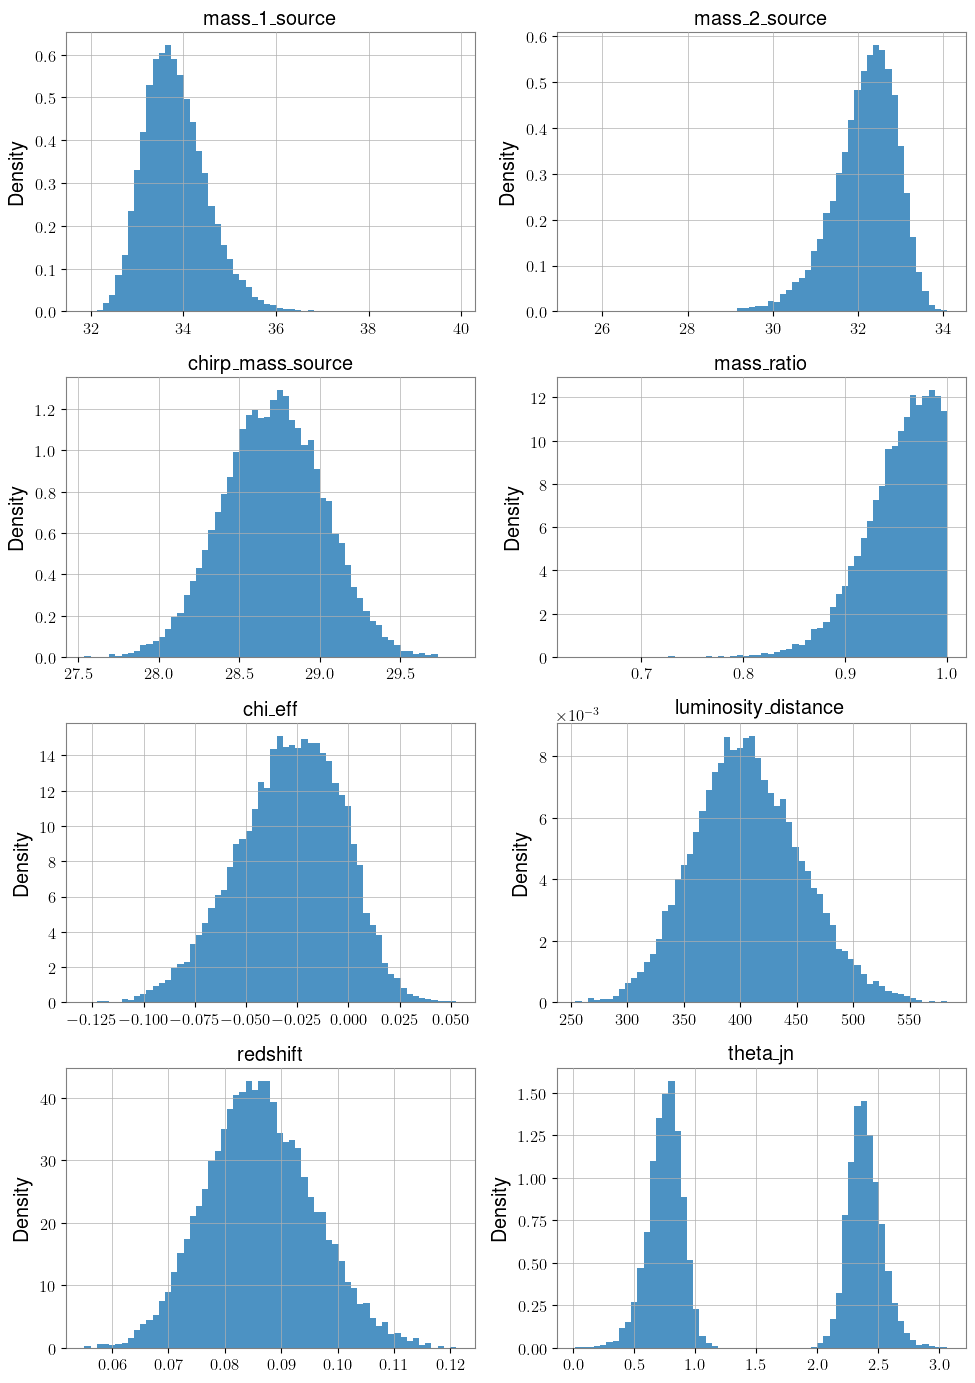

In [16]:
interesting_params = [
    "mass_1_source",
    "mass_2_source",
    "chirp_mass_source",
    "mass_ratio",
    "chi_eff",
    "luminosity_distance",
    "redshift",
    "theta_jn",
]
available_params = [p for p in interesting_params if p in posterior]

if len(available_params) == 0:
    available_params = list(posterior.keys())[:4]

ncols = 2
nrows = int(np.ceil(len(available_params) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, param in zip(axes, available_params):
    x = np.asarray(posterior[param])
    ax.hist(x, bins=60, density=True, alpha=0.8)
    ax.set_title(param)
    ax.set_ylabel("Density")

for ax in axes[len(available_params):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
def credible_summary(x, level=0.9):
    alpha = 0.5 * (1 - level)
    lo, med, hi = np.quantile(x, [alpha, 0.5, 1 - alpha])
    return lo, med, hi

summary_rows = []
for param in available_params:
    samples = np.asarray(posterior[param])
    lo, med, hi = credible_summary(samples, level=0.9)
    width = hi - lo
    frac_width = width / np.abs(med) if med != 0 else np.nan
    summary_rows.append((param, med, lo, hi, width, frac_width))

summary_rows = sorted(summary_rows, key=lambda r: np.nan_to_num(r[-1], nan=np.inf))
print("Parameter, median, 5%, 95%, 90% width, fractional width")
for row in summary_rows:
    print(row)

Parameter, median, 5%, 95%, 90% width, fractional width
('chirp_mass_source', 28.714687265004446, 28.200892101996192, 29.217173929537573, 1.0162818275413805, 0.03539240452672306)
('mass_1_source', 33.763310569992996, 32.86618326496876, 35.044392166432765, 2.1782089014640036, 0.06451407947536632)
('mass_2_source', 32.262775970598746, 30.797487852075218, 33.21234185858858, 2.4148540065133624, 0.07484954204542203)
('mass_ratio', 0.9576843713041711, 0.8853482917882655, 0.9956737534733112, 0.11032546168504576, 0.11520023192485114)
('redshift', 0.0859553825499466, 0.07120416381613827, 0.10256056216174073, 0.03135639834560246, 0.36479854333010514)
('luminosity_distance', 404.7475100069622, 331.91779338062105, 488.33618673149357, 156.41839335087252, 0.3864591862422623)
('theta_jn', 0.9689948934678408, 0.5660371291971641, 2.565415817375336, 1.9993786881781719, 2.0633531731243613)
('chi_eff', -0.02722426969767652, -0.07319423583565533, 0.009938607604380112, 0.08313284344003545, 3.053629881103128

In [18]:
def _safe_prob(hist, eps=1e-12):
    p = np.asarray(hist, dtype=float) + eps
    return p / p.sum()


def js_divergence_from_samples(x, y, bins=80):
    x = np.asarray(x)
    y = np.asarray(y)
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan

    px, edges = np.histogram(x, bins=bins, range=(lo, hi), density=False)
    py, _ = np.histogram(y, bins=edges, density=False)

    p = _safe_prob(px)
    q = _safe_prob(py)
    m = 0.5 * (p + q)

    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * (kl_pm + kl_qm)

In [19]:
prior = None
prior_label = None

if hasattr(gw250114_result, "priors"):
    prior_label, prior = get_first_level_dict(gw250114_result.priors)

if prior is None and hasattr(gw250114_result, "prior_samples_dict"):
    prior_label, prior = get_first_level_dict(gw250114_result.prior_samples_dict)

if prior is None:
    print("No prior samples found in this file. JS prior-vs-posterior step is skipped.")
else:
    overlap_params = [p for p in available_params if p in prior]
    if len(overlap_params) == 0:
        print("Prior found, but no overlapping parameters with selected list.")
    else:
        js_scores = []
        for param in overlap_params:
            js = js_divergence_from_samples(posterior[param], prior[param], bins=80)
            js_scores.append((param, js))

        js_scores = sorted(js_scores, key=lambda x: x[1], reverse=True)
        print(f"Prior label: {prior_label}")
        print("JS divergence (higher means stronger data update):")
        for param, js in js_scores:
            print(f"{param:25s}  {js:.4f}")

Prior found, but no overlapping parameters with selected list.


## 3) Wrap-up Questions for Students

1. Which GW250114 parameters are best constrained by the posterior width?
2. Which parameters show the largest JS divergence from the prior?
3. Do those two rankings match perfectly? If not, why might they differ?
4. If you had to publish one plot from this 1-hour exercise, which one best communicates "what was measured"?

Optional extension:
- Compare GW250114 posterior summaries with the population-level trends seen in the catalog challenge.